<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/gps_escenario_2_1_graphs_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== ERROR METRICS =====

CEP50 = 7.274 m
Mean = 7.378 m
Sigma = 4.007 m


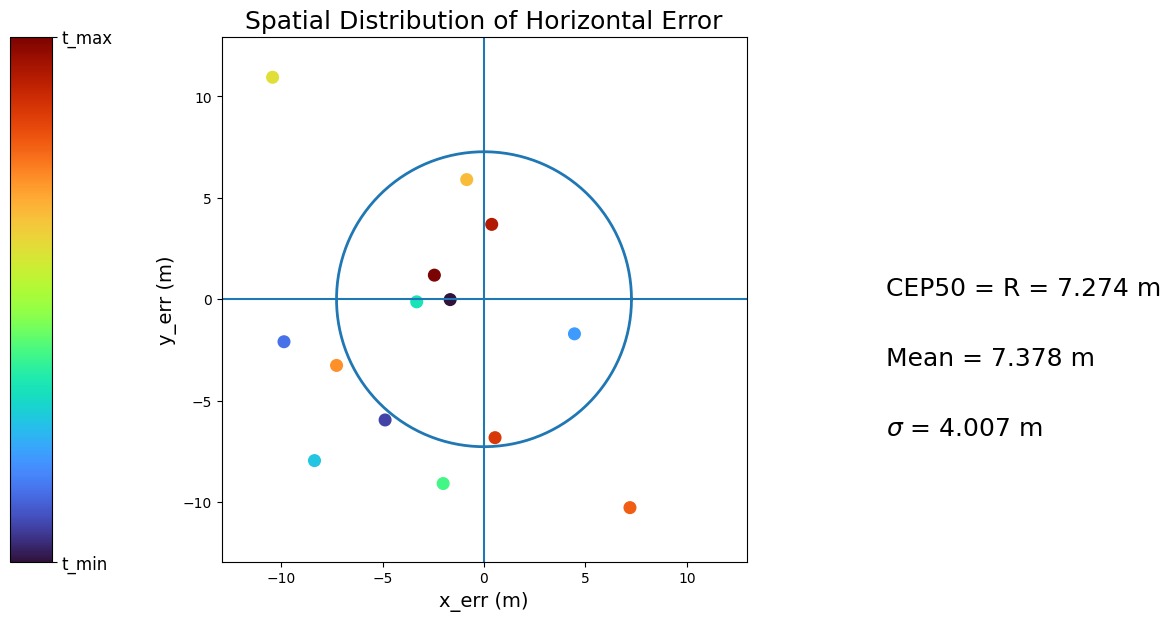

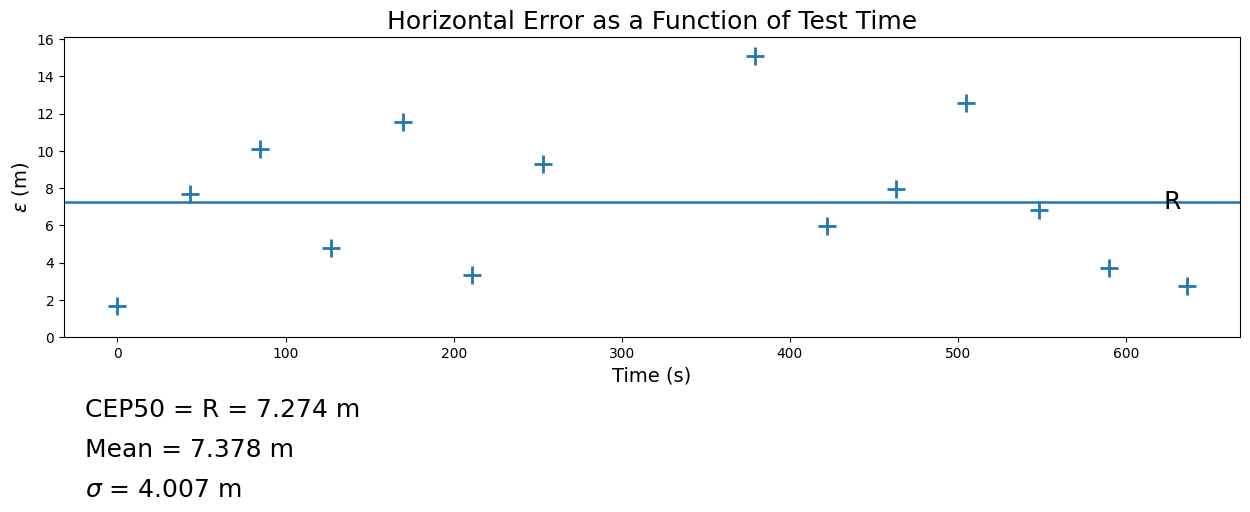

In [3]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos


# ==========================================
# LOAD CSV FILE
# ==========================================

# Upload this file to Colab:
# gps_scenario2_1.csv

file_path = "/content/sample_data/gps_scenario2_1.csv"

df = pd.read_csv(file_path)


# ==========================================
# DATA CLEANING
# ==========================================

# Remove extra spaces from column names
df.columns = [c.strip() for c in df.columns]


# ==========================================
# RENAME COLUMNS
# ==========================================

df.rename(columns={

    "Hora EC": "Hora",

    "Lat EC": "Latitud EC",
    "Lon EC": "Longitud EC",

    "Lat EBP": "Latitud EBP",
    "Lon EBP": "Longitud EBP"

}, inplace=True)


# ==========================================
# NUMERIC CONVERSION
# ==========================================

for col in [

    "Latitud EC",
    "Longitud EC",

    "Latitud EBP",
    "Longitud EBP"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ==========================================
# REMOVE INVALID DATA
# ==========================================

df = df.dropna(
    subset=[
        "Latitud EC",
        "Longitud EC",
        "Latitud EBP",
        "Longitud EBP"
    ]
).copy()


# ==========================================
# FILTER INVALID COORDINATES
# ==========================================

df = df[

    (df["Latitud EC"].between(-90, 90)) &
    (df["Longitud EC"].between(-180, 180)) &

    (df["Latitud EBP"].between(-90, 90)) &
    (df["Longitud EBP"].between(-180, 180))

].copy()


# ==========================================
# TIME CONVERSION
# ==========================================

df["Hora_dt"] = pd.to_datetime(
    df["Hora"],
    format="%H:%M:%S",
    errors="coerce"
)


# Remove invalid timestamps
df = df.dropna(
    subset=["Hora_dt"]
)

df = df.sort_values(
    "Hora_dt"
).reset_index(drop=True)


# ==========================================
# RELATIVE TIME
# ==========================================

df["t_s"] = (
    df["Hora_dt"] - df["Hora_dt"].iloc[0]
).dt.total_seconds()


# ==========================================
# DEGREE TO METER CONVERSION
# ==========================================

lat_mean = df[[
    "Latitud EC",
    "Latitud EBP"
]].mean().mean()

meters_per_deg_lat = 111320

meters_per_deg_lon = (
    111320 *
    cos(radians(lat_mean))
)


# ==========================================
# POSITION ERROR CALCULATION
# ==========================================

df["dlat_deg"] = (
    df["Latitud EC"] -
    df["Latitud EBP"]
)

df["dlon_deg"] = (
    df["Longitud EC"] -
    df["Longitud EBP"]
)

df["y_err_m"] = (
    df["dlat_deg"] *
    meters_per_deg_lat
)

df["x_err_m"] = (
    df["dlon_deg"] *
    meters_per_deg_lon
)

df["eps_m"] = np.sqrt(
    df["x_err_m"]**2 +
    df["y_err_m"]**2
)


# ==========================================
# METRICS
# ==========================================

cep50 = np.percentile(
    df["eps_m"],
    50
)

mean_err = df["eps_m"].mean()

sigma = df["eps_m"].std(ddof=1)


# ==========================================
# PRINT METRICS
# ==========================================

print("\n===== ERROR METRICS =====\n")

print(
    f"CEP50 = "
    f"{cep50:.3f} m"
)

print(
    f"Mean = "
    f"{mean_err:.3f} m"
)

print(
    f"Sigma = "
    f"{sigma:.3f} m"
)


# ==========================================
# FIGURE 1
# SPATIAL ERROR DISTRIBUTION
# ==========================================

fig = plt.figure(figsize=(12, 7))

ax = fig.add_axes([
    0.18,
    0.14,
    0.55,
    0.75
])


# Scatter plot
sc = ax.scatter(
    df["x_err_m"],
    df["y_err_m"],
    c=df["t_s"],
    cmap="turbo",
    s=70
)


# Central axes
ax.axhline(0, linewidth=1.5)

ax.axvline(0, linewidth=1.5)


# CEP50 circle
theta = np.linspace(
    0,
    2*np.pi,
    400
)

ax.plot(
    cep50 * np.cos(theta),
    cep50 * np.sin(theta),
    linewidth=2.0
)


# Plot limits
max_lim = max(

    np.max(np.abs(df["x_err_m"])),

    np.max(np.abs(df["y_err_m"])),

    cep50

) + 2

ax.set_xlim(-max_lim, max_lim)

ax.set_ylim(-max_lim, max_lim)

ax.set_aspect(
    "equal",
    adjustable="box"
)


# Labels
ax.set_xlabel(
    "x_err (m)",
    fontsize=14
)

ax.set_ylabel(
    "y_err (m)",
    fontsize=14
)

ax.set_title(
    "Spatial Distribution of Horizontal Error",
    fontsize=18
)


# ==========================================
# COLORBAR
# ==========================================

cax = fig.add_axes([
    0.06,
    0.14,
    0.035,
    0.75
])

cb = plt.colorbar(
    sc,
    cax=cax
)

cb.set_ticks([
    df["t_s"].min(),
    df["t_s"].max()
])

cb.set_ticklabels([
    "t_min",
    "t_max"
])

cb.ax.tick_params(labelsize=12)


# ==========================================
# METRICS TEXT
# ==========================================

fig.text(
    0.79,
    0.52,
    f"CEP50 = R = {cep50:.3f} m",
    fontsize=18
)

fig.text(
    0.79,
    0.42,
    f"Mean = {mean_err:.3f} m",
    fontsize=18
)

fig.text(
    0.79,
    0.32,
    r"$\sigma$" + f" = {sigma:.3f} m",
    fontsize=18
)

plt.show()


# ==========================================
# FIGURE 2
# HORIZONTAL ERROR VS TIME
# ==========================================

fig2 = plt.figure(figsize=(14, 5))

ax2 = fig2.add_axes([
    0.08,
    0.26,
    0.84,
    0.60
])


# Scatter plot
ax2.scatter(
    df["t_s"],
    df["eps_m"],
    marker="+",
    s=180,
    linewidths=2
)


# CEP50 reference line
ax2.axhline(
    cep50,
    linewidth=1.8
)


# Reference label
ax2.text(
    df["t_s"].max() * 0.995,
    cep50,
    "R",
    ha="right",
    va="center",
    fontsize=18
)


# Labels
ax2.set_xlabel(
    "Time (s)",
    fontsize=14
)

ax2.set_ylabel(
    r"$\epsilon$ (m)",
    fontsize=14
)

ax2.set_title(
    "Horizontal Error as a Function of Test Time",
    fontsize=18
)


# Axis limits
ymax = max(
    df["eps_m"].max(),
    cep50
) + 1

ax2.set_ylim(0, ymax)


# Metrics text
fig2.text(
    0.095,
    0.10,
    f"CEP50 = R = {cep50:.3f} m",
    fontsize=18
)

fig2.text(
    0.095,
    0.02,
    f"Mean = {mean_err:.3f} m",
    fontsize=18
)

fig2.text(
    0.095,
    -0.06,
    r"$\sigma$" + f" = {sigma:.3f} m",
    fontsize=18
)

plt.show()

